# clustering overrides

## summary clustering

In [1]:
from pathlib import Path
import pandas as pd
from tqdm import tqdm


base = Path("../temp/event_windows")

files = list(base.glob("*/*.csv"))

dfs = []

for f in tqdm(files, desc="reading files"):
    df = pd.read_csv(f)
    df["source_file"] = f.name
    dfs.append(df)

reading files: 100%|██████████| 10192/10192 [00:24<00:00, 422.16it/s]


In [6]:
import numpy as np


def extract_features(df):

    df = df.drop(columns=[
        "Timestamp",
        "is_override_point",
        "VP_RP_80.Latitude",
        "VP_RP_80.Longitude",
        "VDS_FC.Altitude"
    ], errors="ignore")

    features = {}

    for col in df.columns:

        x = df[col].values

        features[f"{col}_mean"] = np.nanmean(x)
        features[f"{col}_std"] = np.nanstd(x)
        features[f"{col}_min"] = np.nanmin(x)
        features[f"{col}_max"] = np.nanmax(x)
        features[f"{col}_delta"] = np.nan_to_num(x[-1]) - np.nan_to_num(x[0])

        mask = ~np.isnan(x)

        if mask.sum() > 2:
            slope = np.polyfit(np.arange(len(x))[mask], x[mask], 1)[0]
        else:
            slope = 0

        features[f"{col}_slope"] = slope

    return features

rows = #files

columns ≈ (#signals × 6 features)

In [7]:
rows = []
names = []

for f in tqdm(files, desc="creating data"):
    df = pd.read_csv(f)
    rows.append(extract_features(df))
    names.append(f.name)

X = pd.DataFrame(rows)
X.index = names

creating data: 100%|██████████| 10192/10192 [01:40<00:00, 101.24it/s]


In [8]:
X.isna().sum().sort_values(ascending=False).head()

iQC1.iQCMode_mean     0
iQC1.iQCMode_std      0
iQC1.iQCMode_min      0
iQC1.iQCMode_max      0
iQC1.iQCMode_delta    0
dtype: int64

In [9]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
from sklearn.decomposition import PCA


pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

In [12]:
import hdbscan


clusterer = hdbscan.HDBSCAN(
    min_cluster_size=5,
    min_samples=3
)

labels = clusterer.fit_predict(X_pca)

/home/jrmcmill/Traxen_Driver_Override/.venv/lib/python3.13/site-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


In [13]:
results = pd.DataFrame({
    "file": names,
    "cluster": labels
})

results.sort_values("cluster")

,file,cluster
40,event_179_THROTTLE_OVERRIDE_2025-11-02_04-11-2...,-1
9798,event_800_UNKNOWN_2025-11-25_00-46-09.017000.csv,-1
9751,event_1035_UNKNOWN_2025-11-26_06-26-46.156000.csv,-1
9713,event_651_UNKNOWN_2025-11-22_01-33-35.289000.csv,-1
9570,event_003_UNKNOWN_2025-11-17_00-20-17.516000.csv,-1
...,...,...
10188,event_547_THROTTLE_OVERRIDE_2025-11-22_00-06-4...,2
10189,event_252_THROTTLE_OVERRIDE_2025-11-20_02-31-0...,2
10190,event_144_THROTTLE_OVERRIDE_2025-11-19_01-49-2...,2
10191,event_877_UNKNOWN_2025-11-25_01-58-30.420000.csv,2


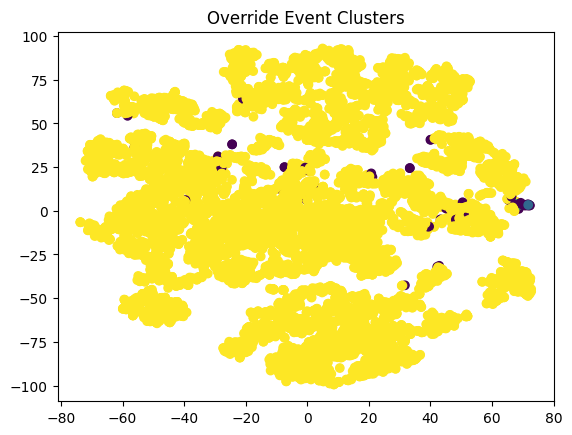

In [14]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt


emb = TSNE(n_components=2).fit_transform(X_pca)

plt.scatter(emb[:,0], emb[:,1], c=labels)
plt.title("Override Event Clusters")
plt.show()

## embedding clustering

In [16]:
import numpy as np
import pandas as pd

from pathlib import Path
from tqdm import tqdm

from sklearn.preprocessing import StandardScaler

import umap
import hdbscan

import matplotlib.pyplot as plt

/home/jrmcmill/Traxen_Driver_Override/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [17]:
base = Path("../temp/event_windows")

files = list(base.glob("*/*.csv"))

print("Total event files:", len(files))

Total event files: 10192


In [18]:
DROP_COLS = [
    "Timestamp",
    "is_override_point",
    "VP_RP_80.Latitude",
    "VP_RP_80.Longitude",
    "VDS_FC.Altitude",
    "EH_not_localized.EH_not_localized"
]

200 rows × signals → flattened vector

In [20]:
vectors = []
file_names = []

for f in tqdm(files, desc="Processing events"):

    df = pd.read_csv(f)

    # drop unwanted columns
    df = df.drop(columns=DROP_COLS, errors="ignore")

    # convert obvious invalid sensor values
    df.replace([255, 65535], np.nan, inplace=True)

    # forward/backward fill (pandas >=2.1 compatible)
    df = df.ffill().bfill().fillna(0)

    # ensure consistent column ordering
    df = df.sort_index(axis=1)

    # flatten time-series window → vector
    vec = df.to_numpy().flatten()

    vectors.append(vec)
    file_names.append(f.name)

# convert to matrix
X = np.vstack(vectors)

print("Feature matrix shape:", X.shape)

Processing events: 100%|██████████| 10192/10192 [00:41<00:00, 242.74it/s]


Feature matrix shape: (10192, 4200)


In [21]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [22]:
umap_model = umap.UMAP(
    n_neighbors=20,
    n_components=15,
    min_dist=0.0,
    metric="euclidean",
    random_state=42
)

X_embedding = umap_model.fit_transform(X_scaled)

print(X_embedding.shape)

/home/jrmcmill/Traxen_Driver_Override/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(10192, 15)


In [23]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=10,
    min_samples=5,
    metric="euclidean",
    cluster_selection_method="eom"
)

labels = clusterer.fit_predict(X_embedding)

print("Clusters found:", len(set(labels)) - (1 if -1 in labels else 0))

Clusters found: 42


-1 = noise / outliers

0..N = clusters

In [24]:
results = pd.DataFrame({
    "file": file_names,
    "cluster": labels
})

results.sort_values("cluster").head(20)

,file,cluster
901,event_601_THROTTLE_OVERRIDE_2025-11-06_01-00-3...,-1
910,event_1759_THROTTLE_OVERRIDE_2025-11-16_02-24-...,-1
912,event_955_UNKNOWN_2025-11-09_01-03-02.689000.csv,-1
9960,event_811_THROTTLE_OVERRIDE_2025-11-25_00-55-2...,-1
8544,event_448_THROTTLE_OVERRIDE_2025-11-09_12-47-5...,-1
8547,event_728_THROTTLE_OVERRIDE_2025-11-14_04-39-1...,-1
8555,event_148_THROTTLE_OVERRIDE_2025-11-04_03-11-1...,-1
8556,event_108_THROTTLE_OVERRIDE_2025-11-04_00-58-3...,-1
918,event_2417_THROTTLE_OVERRIDE_2025-11-23_03-19-...,-1
924,event_170_THROTTLE_OVERRIDE_2025-11-02_03-42-2...,-1


In [25]:
results["cluster"].value_counts().sort_index()

cluster
-1      725
 0     4255
 1      482
 2      164
 3       74
 4      118
 5     1952
 6       97
 7       11
 8       54
 9       25
 10      65
 11      37
 12      21
 13     211
 14     131
 15      69
 16      17
 17      13
 18      40
 19      20
 20     188
 21      60
 22      23
 23      29
 24      12
 25      39
 26      29
 27      58
 28      23
 29      12
 30     277
 31      22
 32      26
 33      21
 34      10
 35      45
 36      12
 37      43
 38      90
 39      31
 40     435
 41     126
Name: count, dtype: int64

In [26]:
umap_2d = umap.UMAP(
    n_neighbors=20,
    n_components=2,
    min_dist=0.0,
    metric="euclidean",
    random_state=42
)

X_2d = umap_2d.fit_transform(X_scaled)

/home/jrmcmill/Traxen_Driver_Override/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


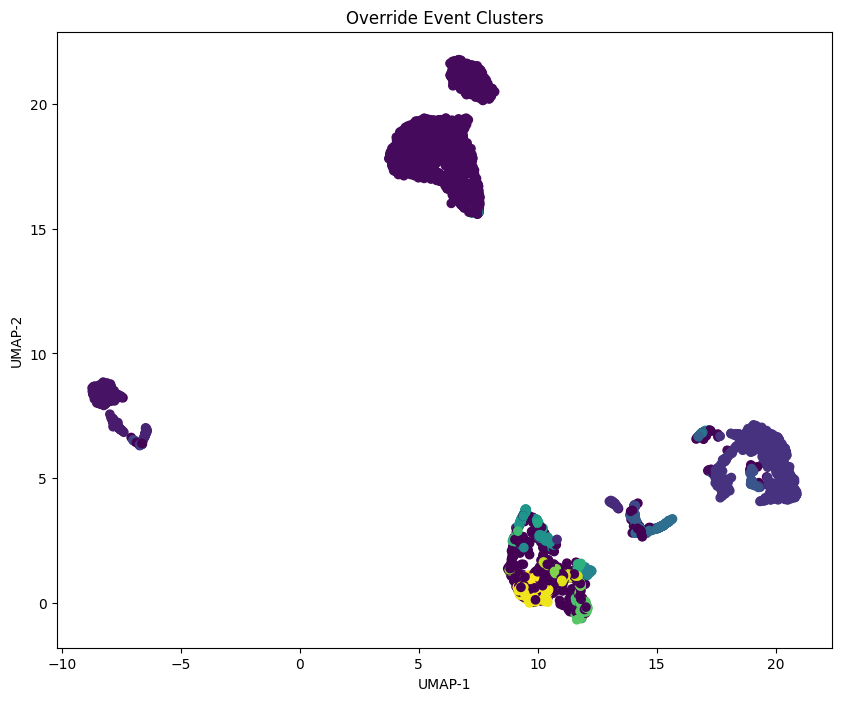

In [27]:
plt.figure(figsize=(10,8))

scatter = plt.scatter(
    X_2d[:,0],
    X_2d[:,1],
    c=labels,
)

plt.title("Override Event Clusters")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")

plt.show()

In [28]:
cluster_id = 0

cluster_files = results[results.cluster == cluster_id]["file"]

cluster_files.head()

0    event_1122_UNKNOWN_2025-11-10_02-00-02.360000.csv
1    event_2190_BRAKE_PEDAL_2025-11-21_02-30-38.267...
2    event_1312_THROTTLE_OVERRIDE_2025-11-11_02-17-...
3    event_2163_THROTTLE_OVERRIDE_2025-11-21_01-16-...
4    event_1316_THROTTLE_OVERRIDE_2025-11-11_02-20-...
Name: file, dtype: str

In [29]:
results.to_csv("override_event_clusters.csv", index=False)